In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")

# Load the graph
print("Loading graph...")
data = torch.load(
    r'C:\Users\varun\Desktop\fraud-gnn\data\graph_data.pt',
    map_location=torch.device('cpu'),
    weights_only=False
)
print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.num_edges}")
print(f"Node features: {data.num_node_features}")
print("✅ Graph loaded!")

PyTorch version: 2.6.0+cpu
Loading graph...
Nodes: 2376
Edges: 10000
Node features: 11
✅ Graph loaded!


In [2]:
# Define the GNN Model
class FraudGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(FraudGNN, self).__init__()
        
        # Two GraphSAGE convolution layers
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        
        # Final classifier
        self.classifier = nn.Linear(hidden_channels, out_channels)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(p=0.5)
        
    def forward(self, x, edge_index):
        # Layer 1
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Layer 2
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Classification
        x = self.classifier(x)
        return x

# Initialize model
model = FraudGNN(
    in_channels=data.num_node_features,  # 11
    hidden_channels=64,
    out_channels=2  # fraud or not fraud
)

print("=== MODEL ARCHITECTURE ===")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

=== MODEL ARCHITECTURE ===
FraudGNN(
  (conv1): SAGEConv(11, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Total parameters: 9,858


In [3]:
from torch_geometric.utils import train_test_split_edges
import torch.optim as optim

# Create train/test masks
torch.manual_seed(42)
num_nodes = data.num_nodes
indices = torch.randperm(num_nodes)

train_size = int(0.8 * num_nodes)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)
train_mask[indices[:train_size]] = True
test_mask[indices[train_size:]] = True

print(f"Training nodes: {train_mask.sum().item()}")
print(f"Testing nodes: {test_mask.sum().item()}")

# Handle class imbalance
fraud_count = data.y.sum().item()
normal_count = num_nodes - fraud_count
weight = torch.tensor([1.0, normal_count/fraud_count])
print(f"\nClass weights: {weight}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss(weight=weight)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
print("\nTraining GNN...")
model.train()
losses = []

for epoch in range(100):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/100 | Loss: {loss.item():.4f}")

print("\n✅ Training complete!")

Training nodes: 1900
Testing nodes: 476

Class weights: tensor([ 1.0000, 10.8209])

Training GNN...
Epoch 10/100 | Loss: 1.1225
Epoch 20/100 | Loss: 0.7394
Epoch 30/100 | Loss: 0.7133
Epoch 40/100 | Loss: 0.6992
Epoch 50/100 | Loss: 0.6883
Epoch 60/100 | Loss: 0.6878
Epoch 70/100 | Loss: 0.6770
Epoch 80/100 | Loss: 0.6690
Epoch 90/100 | Loss: 0.6739
Epoch 100/100 | Loss: 0.6728

✅ Training complete!


=== MODEL EVALUATION ===
              precision    recall  f1-score   support

  Legitimate       0.96      0.31      0.47       437
       Fraud       0.10      0.85      0.18        39

    accuracy                           0.36       476
   macro avg       0.53      0.58      0.32       476
weighted avg       0.89      0.36      0.45       476



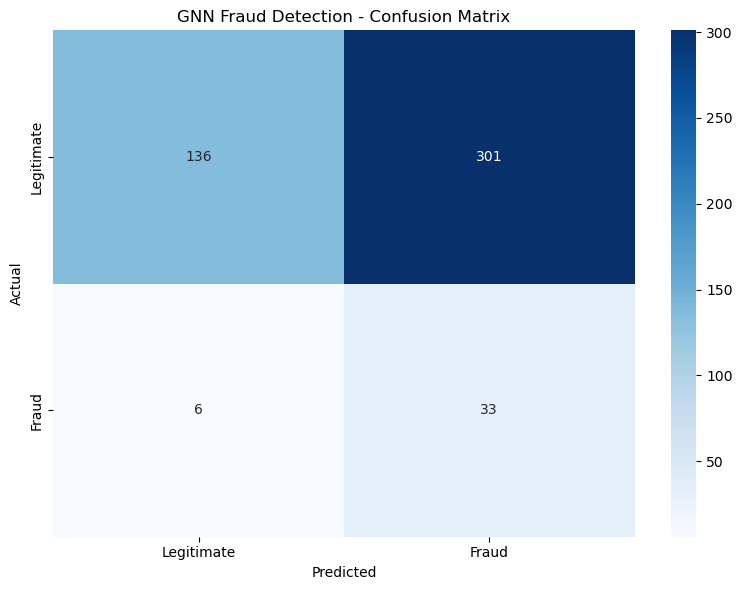

✅ Evaluation complete!


In [4]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    
    # Test set predictions
    test_pred = pred[test_mask].numpy()
    test_true = data.y[test_mask].numpy()

print("=== MODEL EVALUATION ===")
print(classification_report(test_true, test_pred, 
      target_names=['Legitimate', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(test_true, test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('GNN Fraud Detection - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(r'C:\Users\varun\Desktop\fraud-gnn\notebooks\confusion_matrix.png')
plt.show()
print("✅ Evaluation complete!")

✅ Model saved!


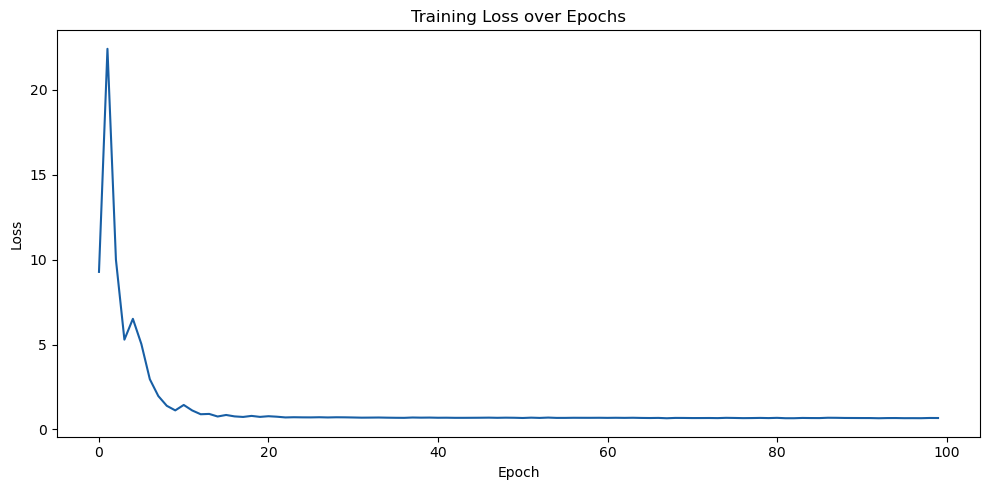

✅ Loss plot saved!


In [5]:
# Save the trained model
torch.save(model.state_dict(), 
           r'C:\Users\varun\Desktop\fraud-gnn\models\fraud_gnn_model.pt')
print("✅ Model saved!")

# Plot training loss
plt.figure(figsize=(10,5))
plt.plot(losses, color='#185FA5')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig(r'C:\Users\varun\Desktop\fraud-gnn\notebooks\training_loss.png')
plt.show()
print("✅ Loss plot saved!")